<a href="https://colab.research.google.com/github/iqra-ai-engineer/assignment_piaic/blob/main/Assignment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Trainee: Iqra Tahir
Roll No: PIAIC234522
Assignment # 6

In [3]:
!pip install langchain_google_genai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.6 MB/s eta 0:00:00


In [4]:
import os
import google.generativeai as genai
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.prompts import ChatPromptTemplate
from langchain.chains import LLMChain

In [5]:
from google.colab import userdata
GOOGLE_API_KEY=userdata.get('Gemini_Api_Key')
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY


In [22]:
gemini_pro = ChatGoogleGenerativeAI(model="gemini-pro", temperature=0.0)
gemini = ChatGoogleGenerativeAI(model="gemini-2.0-flash-exp", temperature=0.0)


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
video_path = '/content/drive/My Drive/video.mp4'


Frames Extracted successfully


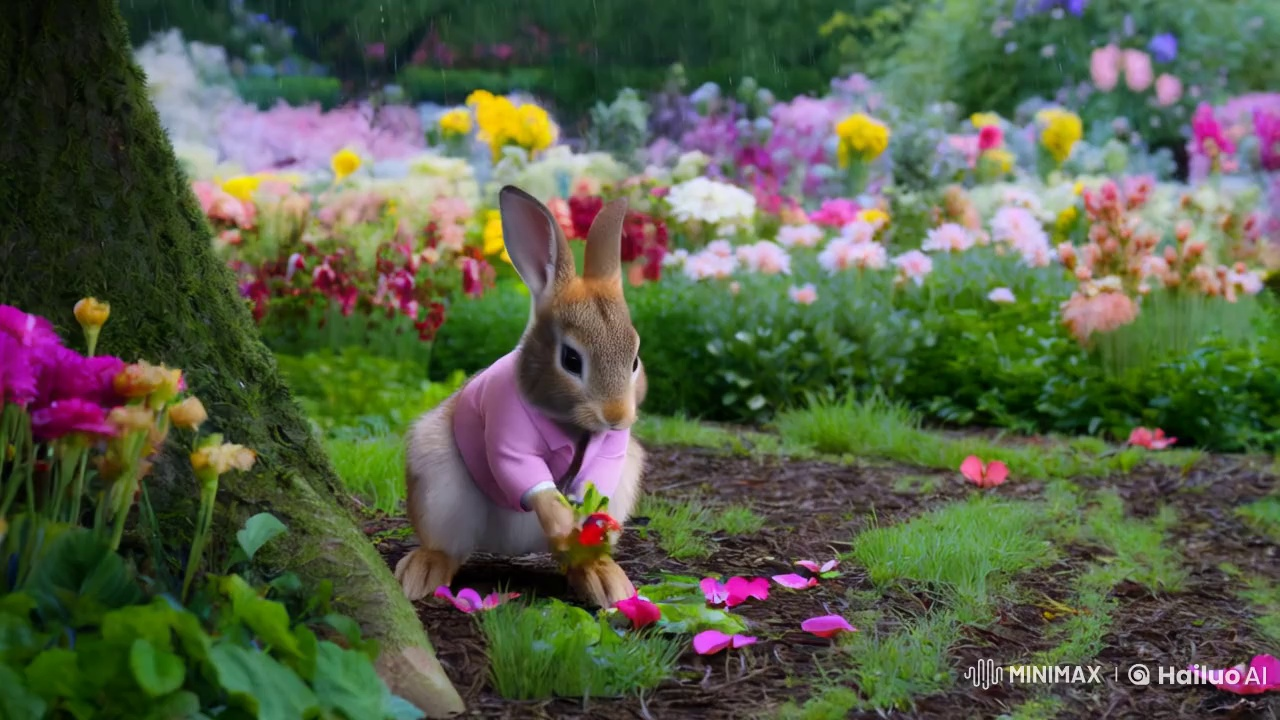

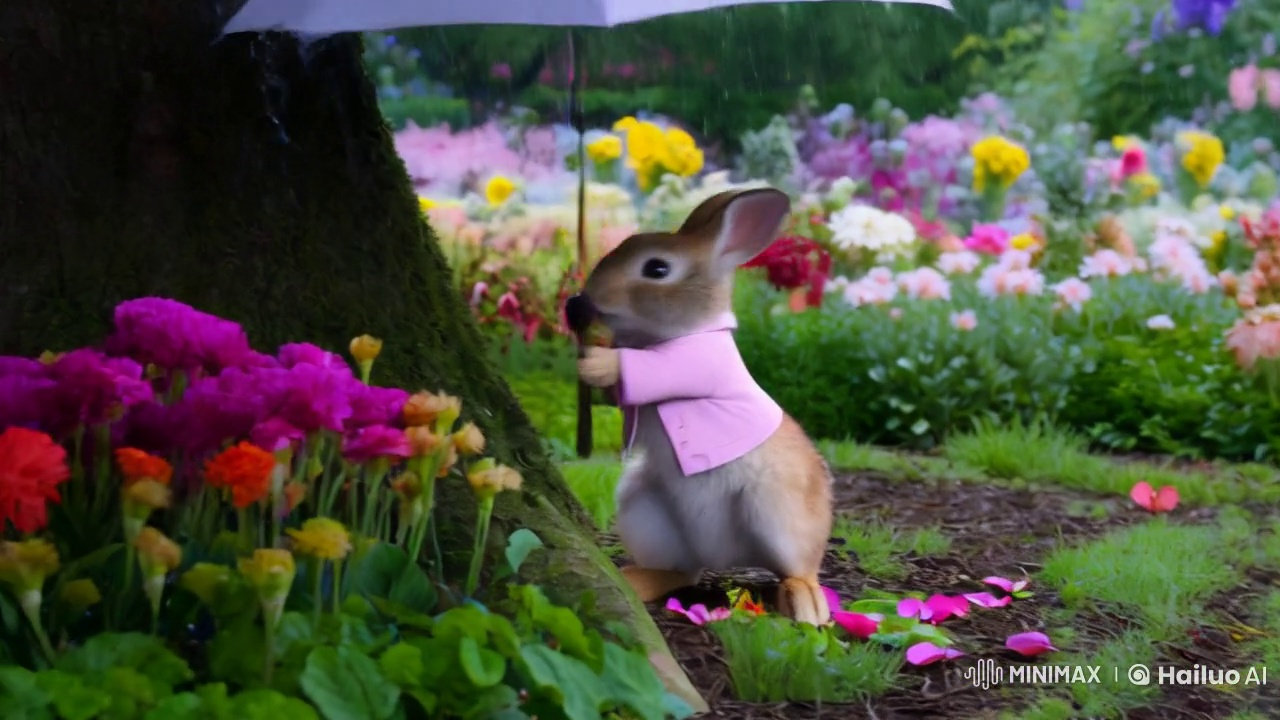

Image input prepared


In [19]:
!pip install opencv-python
import cv2
import os
from google.colab import files
import base64
from IPython.display import Image
import io

def extract_frames(video_path, num_frames=5):
  """Extracts evenly spaced frames from a video.

  Args:
    video_path: Path to the video file.
    num_frames: The number of frames to extract.

  Returns:
    A list of image filepaths.
  """
  frames = []
  try:
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        print(f"Error: Could not determine the number of frames or video is invalid at path {video_path}")
        return []

    if num_frames > total_frames:
      num_frames = total_frames # Adjust num_frames to not be greater than the number of frames

    frame_indices = [int((i * total_frames) / num_frames) for i in range(num_frames)]

    for index in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, index)
        ret, frame = cap.read()
        if ret:
            frame_name = f"frame_{index}.jpg"
            cv2.imwrite(frame_name, frame)
            frames.append(frame_name)
        else:
            print(f"Error reading frame at index: {index}")
    cap.release()

  except Exception as e:
     print(f"An error occurred: {e}")
  return frames

def display_frames(image_paths, max_width = 200):
  """Display extracted frames for checking"""
  for image_path in image_paths:
    try:
        display(Image(filename=image_path, width = max_width))
    except Exception as e:
        print(f"Error displaying image at {image_path}. Error {e}")


def prepare_image_input(image_paths):
    """Converts image paths to content parts for gemini"""
    image_parts = []
    for image_path in image_paths:
        try:
            with open(image_path, "rb") as f:
                image_data = f.read()
                image_part = {
                    "mime_type": "image/jpeg",
                    "data": base64.b64encode(image_data).decode("utf-8")
                }
                image_parts.append(image_part)
        except Exception as e:
            print(f"Error loading image at path {image_path}: Error {e}")
    return image_parts
num_frames_to_extract = 2

extracted_frames = extract_frames(video_path, num_frames_to_extract)

if extracted_frames:
    print("Frames Extracted successfully")
    display_frames(extracted_frames, max_width = 300)
    image_parts = prepare_image_input(extracted_frames)
    print("Image input prepared")
else:
    print("No frames extracted")


In [23]:


# Craft the Prompt Template
template = """
You are a video analysis expert. You will be provided with a series of image frames extracted from a video. Your goal is to analyze these frames and create a detailed script with a timeline, based on your understanding of the overall narrative.

Here's how you should format the script:
- **Timeline Format**: Present each scene as a sequential event in a timeline. For each scene, note down an approximate timestamp (if possible, estimate based on sequence)
- **Scene Description**: Provide a concise description of the visual elements in the scene, including the setting, characters, objects, and actions.
- **Dialogue/Narrative**: If there appears to be any dialogue or narrative elements, summarize them. If the scene has no evident dialog or narrative content, indicate it.

Here are the extracted frames. Analyze these frames and create a detailed script:
{image_parts}

Remember to keep track of scene changes and events, and present them as a structured timeline.
"""

prompt = ChatPromptTemplate.from_template(template)

# Create the LLMChain with the gemini-2.0-flash-exp model
chain = LLMChain(llm=gemini, prompt=prompt)


# Call Gemini with the prepared Image parts
if image_parts:
  response = chain.invoke({"image_parts": image_parts})
  print("Gemini Response Received:\n")
  print(response['text'])
else:
  print("No image parts available. Cannot send to Gemini.")


# Clean up frame files
for image_path in extracted_frames:
  try:
    os.remove(image_path)
  except Exception as e:
     print(f"Failed to delete file {image_path}. Error: {e}")
print("Frame files deleted.")

Gemini Response Received:

Okay, here's a detailed script based on the provided image frames, formatted as requested:

**Video Analysis Script**

**Timeline:**

*   **0:00 - 0:02 (Estimated)**

    *   **Scene Description**: The scene opens with a close-up shot of a person's hand, specifically the fingers, resting on a surface. The lighting is soft, and the focus is on the texture of the skin and the slight shadows around the fingers. The background is blurred, suggesting a shallow depth of field.
    *   **Dialogue/Narrative**: None.

*   **0:02 - 0:04 (Estimated)**

    *   **Scene Description**: The camera pulls back slightly to reveal more of the hand and the surface it's resting on. The surface appears to be a textured, possibly wooden, table or desk. The lighting remains soft, and the focus is still primarily on the hand.
    *   **Dialogue/Narrative**: None.

*   **0:04 - 0:06 (Estimated)**

    *   **Scene Description**: The camera angle shifts slightly, now showing the hand fr

Challenges:
To complete this assignment was tricky as there were no free Multimodal LLM for text-to-video generation. Some were just giving me video after taking from internet while other were making wrong videos against my prompt.
In Short, i did this...